# KU39 — Integrated preprocessing pipeline and report evidence

This notebook combines the six preparation topics. It follows the final report's nine-section order. Outputs are from the uploaded archive. The generated split is NEW and does not recover the original training history.

## 1. Introduction and Problem Statement
An educational maize leaf image classification system with four folder targets. The group pipeline audits source files, removes exact duplicates, prepares a reproducible partition and demonstrates image transformations.

## 2. Dataset Description
Actual image counts and quality checks follow. The archive has no predefined train/test directories. Confirm provenance before attributing it to the proposal source.

In [1]:
from pathlib import Path
import sys, json, zipfile

# Local: keep this notebook in the extracted project folder.
# Colab: upload KU39_Notebooks_With_Results.zip into My Drive/KU39 first.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'src'/'preprocessing.py').exists() and (p/'data'/'raw'/'archive.zip').exists()), None)
if ROOT is None:
    try:
        from google.colab import drive
    except ImportError:
        raise RuntimeError('Extract the full project ZIP and launch Jupyter from its project folder.')
    drive.mount('/content/drive')
    PACKAGE = Path('/content/drive/MyDrive/KU39/KU39_Notebooks_With_Results.zip')
    if not PACKAGE.exists():
        raise FileNotFoundError('Upload KU39_Notebooks_With_Results.zip into My Drive/KU39, then rerun this cell.')
    destination = Path('/content/KU39_workspace')
    destination.mkdir(exist_ok=True)
    with zipfile.ZipFile(PACKAGE) as z:
        for item in z.infolist():
            target = (destination/item.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError('Unsafe ZIP path')
        z.extractall(destination)
    ROOT = destination/'2026-Y2-S1-KU-39'
sys.path.insert(0, str(ROOT/'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display
from preprocessing import (CLASSES, SEED, audit, clean_and_split, load_image,
    prepare_image, integrity_plot, split_plot, resize_plot, label_plot,
    normalization_plot, augmentation_plot, augment)
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
pd.set_option('display.max_columns', 12)
print('Project ready. CPU runtime is sufficient for these preprocessing notebooks.')

Project ready. CPU runtime is sufficient for these preprocessing notebooks.


In [2]:
# The cache is reused only if the original archive SHA-256 still matches.
manifest = audit(ROOT)
cleaned, duplicate_rows, conflict_rows = clean_and_split(manifest, ROOT)
counts = manifest.groupby('label').size().reindex(CLASSES)
display(counts.rename('raw_image_entries').to_frame())
print('Raw image entries:', len(manifest))
print('Decodable images with known labels:', int(manifest.valid.sum()))
print('Retained after invalid/conflicting/exact duplicate exclusions:', len(cleaned))

Raw image entries: 4188
Decodable images with known labels: 4188
Retained after invalid/conflicting/exact duplicate exclusions: 4184


,raw_image_entries
label,
Blight,1146
Common_Rust,1306
Gray_Leaf_Spot,574
Healthy,1162


## 3. Preprocessing & EDA
Six integrated components: image integrity, duplicates/splits, RGB resize, labels/balance, model-specific input scaling and training augmentation.

In [3]:
summary=pd.DataFrame({'stage':['Raw image entries','Valid decoded/known-label images',
    'Invalid/unknown exclusions','Exact pixel duplicate exclusions','Conflicting-label exclusions','Retained images'],
    'images':[len(manifest),int(manifest.valid.sum()),int((manifest.valid==False).sum()),len(duplicate_rows),len(conflict_rows),len(cleaned)]})
display(summary)
summary.to_csv(ROOT/'results/outputs/group_pipeline_summary.csv',index=False)
display(pd.crosstab(cleaned.label,cleaned.preparation_split).reindex(CLASSES))
print('Class order:',CLASSES)

Class order: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


,stage,images
0,Raw image entries,4188
1,Valid decoded/known-label images,4188
2,Invalid/unknown exclusions,0
3,Exact pixel duplicate exclusions,0
4,Conflicting-label exclusions,4
5,Retained images,4184


preparation_split,test,train,validation
label,,,
Blight,229,686,229
Common_Rust,262,783,261
Gray_Leaf_Spot,114,344,114
Healthy,232,697,233


Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/01_integrity_and_dimensions.png')


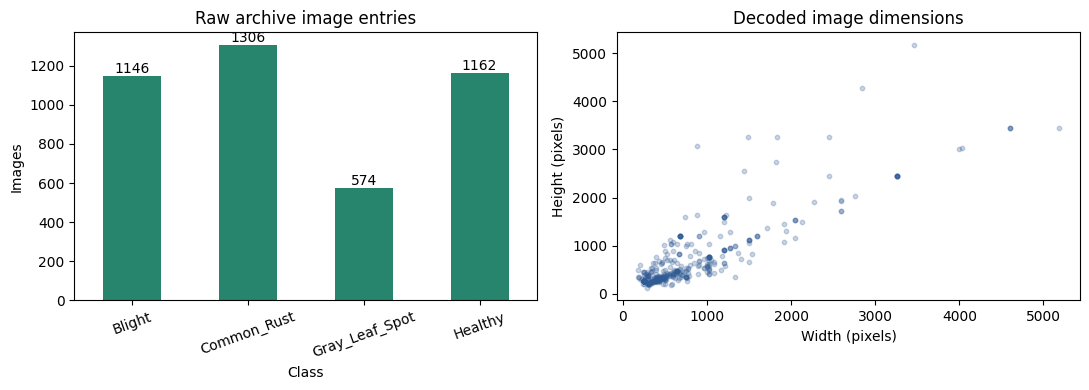

In [4]:
integrity_plot(manifest, ROOT);

Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/02_NEW_preparation_split.png')


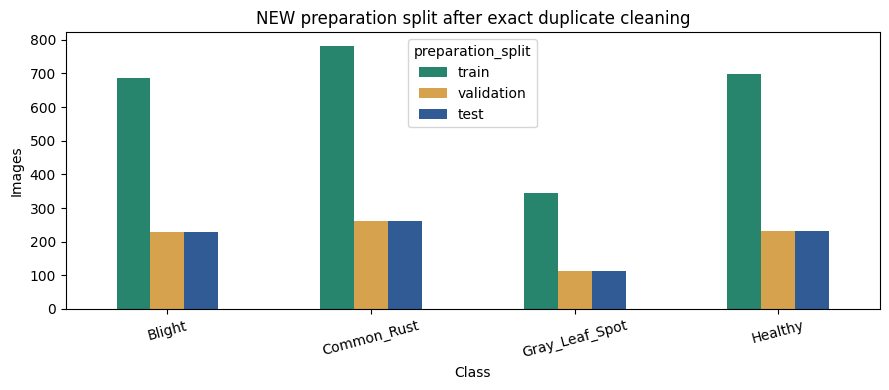

In [5]:
split_plot(cleaned, ROOT);

Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/03_rgb_resize_examples.png')


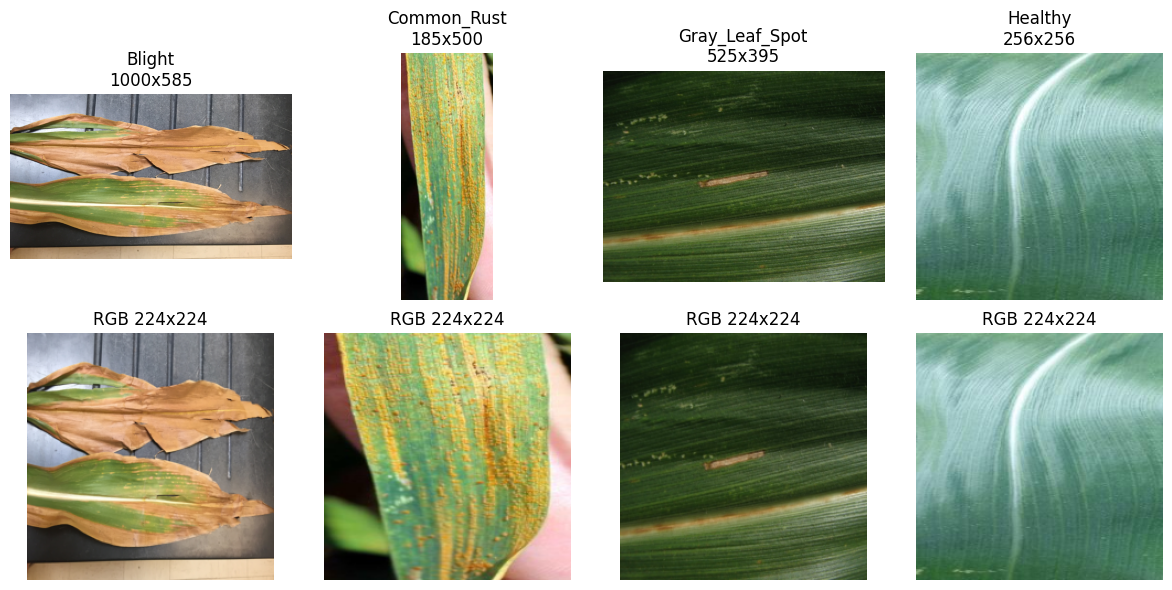

In [6]:
resize_plot(manifest, ROOT);

Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/04_training_class_balance.png')


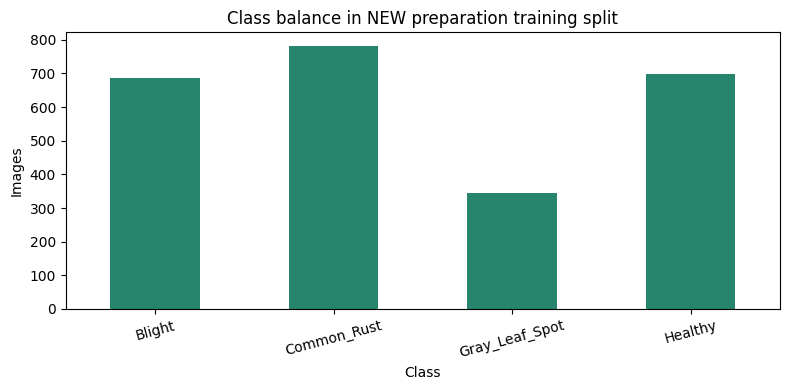

In [7]:
label_plot(cleaned, ROOT);

Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/05_model_input_ranges.png')


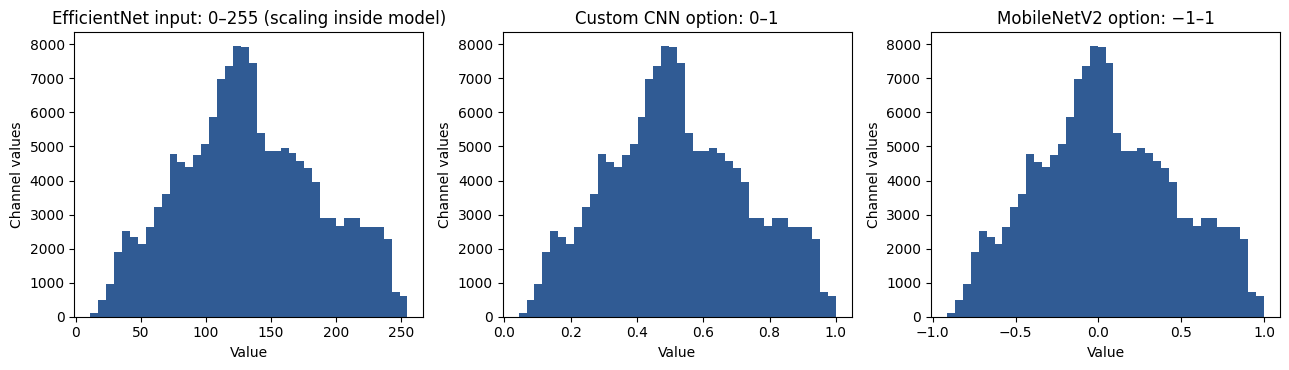

In [8]:
normalization_plot(cleaned, ROOT);

Out[0]: PosixPath('/workspace/scratch/44a2b5908dd2/deliverables/2026-Y2-S1-KU-39/results/eda_visualizations/06_training_only_augmentation.png')


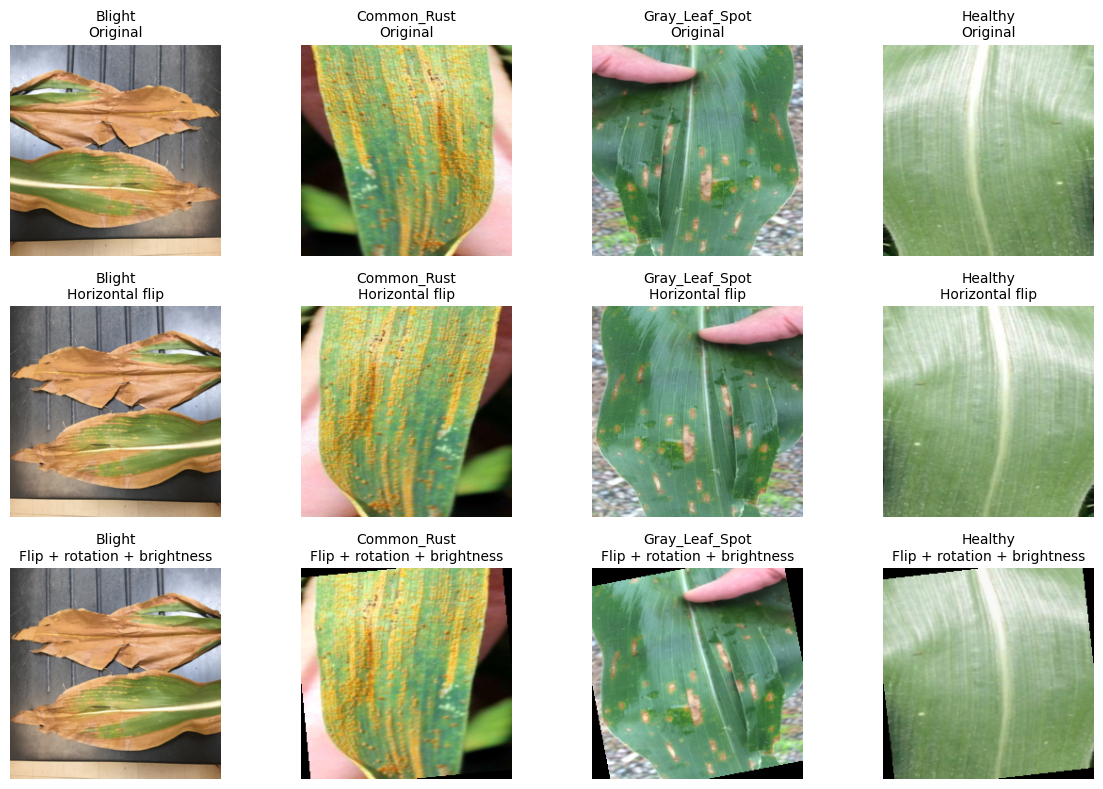

In [9]:
augmentation_plot(cleaned, ROOT);

In [10]:
# Export deterministic resized samples, plus all manifests/features.
# Full transformed image tensors need not be stored; loading can resize on demand.
sample_dir=ROOT/'results/outputs/processed_samples'
sample_dir.mkdir(exist_ok=True)
for label in CLASSES:
    row=cleaned[(cleaned.label==label)&(cleaned.preparation_split=='train')].sort_values('path').iloc[0]
    x=prepare_image(load_image(ROOT,row.path))
    Image.fromarray(x.astype('uint8')).save(sample_dir/f'{label}.png')
cleaned[['path','label','label_id','width','height','mean_brightness','contrast','preparation_split']].to_csv(
    ROOT/'results/outputs/processed_features.csv',index=False)
print('Saved full processed feature manifest, class mapping, exclusion logs and four 224x224 example images.')
print('Deterministic resizing is reproducible on demand from the immutable raw archive.')

Saved full processed feature manifest, class mapping, exclusion logs and four 224x224 example images.
Deterministic resizing is reproducible on demand from the immutable raw archive.


## 4. Model Design and Implementation
The task is four-class maize leaf image classification. The supplied website contains an EfficientNetB0 artifact. Its input contract is RGB, 224×224, float32 values in 0–255; scaling is inside the model. Custom CNN and MobileNetV2 were proposed but their training evidence is not in the supplied files.

This notebook implements and evaluates a preprocessing component. No classifier is trained here. The **new preparation split is not the original trained model's split**. Do not evaluate the already trained model on this split and call it an independent test.

In [11]:
import hashlib
info=json.loads((ROOT/'website/model/model_info.json').read_text())
assert hashlib.sha256((ROOT/'website/model/model.keras').read_bytes()).hexdigest()==info['sha256']
display(pd.DataFrame([{'model':info['model'],'reported_accuracy':info['test_accuracy'],
 'reported_macro_f1':info['test_macro_f1'],'reported_test_images':info['test_images'],
 'verification':'Metadata only; original predictions absent'}]))

,model,reported_accuracy,reported_macro_f1,reported_test_images,verification
0,efficientnet_b0,0.935407,0.913174,836,Metadata only; original predictions absent


## 5. Evaluation and Comparison

**Completed here:** full image decode audit; exact pixel/file duplicate checks; conflict handling; partition overlap assertions; stable labels; transformation range/shape checks; saved EDA figures and outputs.

**Not completed or recovered:** classifier training; hyperparameter search; model k-fold scores; independent test evaluation; comparison of Custom CNN, MobileNetV2 and EfficientNetB0. Existing website metadata is not a substitute for these experiments. K-fold partition creation is not k-fold model evaluation.

The final report must use original experiment evidence or accurately document newly executed experiments with a fresh model and a locked leakage-controlled protocol.

## 6. Ethical Considerations and Bias Mitigation
- Preserve raw images and record exclusions instead of deleting source evidence.
- Inspect the smaller Gray_Leaf_Spot class and report class-level performance when original evaluation evidence is recovered.
- Exact duplicate removal does not establish absence of near duplicates, same-plant overlap or source bias.
- Controlled dataset findings do not demonstrate performance on real farm photos.
- The website does not implement non-maize rejection. Scores are not guarantees or treatment advice.

## 7. AI Tool Usage Declaration and Transparency
ChatGPT/Codex assisted with the source inspection, notebook code, figures and explanations in this preparation package. The preprocessing cells were executed on the supplied archive and outputs were saved. Each member must rerun, inspect and understand their assigned code, document corrections, and declare their actual contribution. This assignment is proposed ownership; it is not evidence that this member authored the earlier model.

The original model's reported test metrics have not been independently reproduced here. Record actual training-related AI usage separately.

## 8. Reflections and Lessons Learned
**Observed technical lesson:** preprocessing decisions must be reproducible and traceable to the original files. A successful website and a preprocessing notebook do not replace model-comparison and cross-validation evidence.

**Personal reflection to complete after your own work:**
1. What did I run, verify or change?
2. What issue did I find and how did I resolve it?
3. Which output can I explain and what is its limitation?
4. What is my actual commit/PR link?

Do not present the prepared notes as a completed personal reflection.

## 9. References
- Supplied **Progress Review I - Data Preprocessing and EDA**: individual technique, implementation/output, EDA visualization and integrated pipeline requirements.
- Supplied **Final Evaluation - Documentation**: nine report sections, maximum 15 pages, group-ID PDF title.
- Supplied **Group Assignment Specification**: at least two models, tuning and k-fold cross-validation.
- Actual supplied `archive(1).zip`, copied unchanged to `data/raw/archive.zip`.
- Supplied website `model/model_info.json` and `app.py`, preserved under `website/`.
- Pillow API: https://pillow.readthedocs.io/en/stable/reference/Image.html
- scikit-learn StratifiedGroupKFold: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html

The proposal's IEEE dataset URL is a provenance lead. Its connection to this differently structured archive still needs confirmation.

### Save new results to Google Drive after rerunning (optional)
The prepared ZIP already includes saved notebook outputs. A Colab rerun writes local CSVs/PNGs to `/content/KU39_workspace`; run the next cell to copy those outputs to Drive. Save the notebook itself with File → Save a copy in Drive after execution.

In [12]:
if Path('/content/drive/MyDrive').exists():
    import shutil
    target=Path('/content/drive/MyDrive/KU39/latest_results')
    shutil.copytree(ROOT/'results',target,dirs_exist_ok=True)
    print('Copied CSVs, figures and logs to My Drive/KU39/latest_results.')
else:
    print('Local run: outputs are already in the project results folder.')

Local run: outputs are already in the project results folder.
